In [1]:
!pip install harmonypy=='0.0.9'

  Attempting uninstall: harmonypy
    Found existing installation: harmonypy 0.0.5
    Uninstalling harmonypy-0.0.5:
      Successfully uninstalled harmonypy-0.0.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [2]:
!pip install anndata=='0.8.0'

In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
import anndata as ad
from sklearn.manifold import TSNE

In [ ]:
#input: combined h5ad of data
#output: SAM object

In [2]:
fn = 'Testing_Raw_Dat_RNASEQ_Joined/tot_dat_CJ_nonneuron_geneexp_cleaned_06082026.h5ad'

In [3]:
dataframe = sc.read_h5ad(fn)

In [5]:
np.sort(dataframe.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique())

array(['318 Astro-NT NN', '319 Astro-TE NN', '322 Tanycyte NN',
       '323 Ependymal NN', '325 CHOR NN', '326 OPC NN', '327 Oligo NN',
       '329 ABC NN', '330 VLMC NN', '333 Endo NN',
       '339 astrocyte-like NN', '340 vascular cells NN',
       '341 macrophages NN', 'Unlabeled', 'cj_0', 'cj_22'], dtype=object)

In [13]:
dataframe.obs['ss_subclass_nounlabeled_nmm_v3_nn'].value_counts()

327 Oligo NN             9265
318 Astro-NT NN          3043
326 OPC NN               2328
339 astrocyte-like NN    2083
Unlabeled                 525
330 VLMC NN               450
322 Tanycyte NN           359
323 Ependymal NN          244
341 macrophages NN        231
319 Astro-TE NN           222
329 ABC NN                142
333 Endo NN                39
340 vascular cells NN      36
325 CHOR NN                28
cj_0                        4
cj_22                       2
Name: ss_subclass_nounlabeled_nmm_v3_nn, dtype: int64

In [18]:
np.sort(dataframe.obs[''].unique())

array(['054 STR Prox1 Lhx6 Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '058 PAL-STR Gaba-Chol', '061 STR D1 Gaba', '069 LSX Nkx2-1 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '074 MEA-BST Lhx6 Sp9 Gaba',
       '077 CEA-BST Gal Avp Gaba', '082 CEA-BST Ebf1 Pdyn Gaba',
       '085 SI-MPO-LPO Lhx8 Gaba', '086 MPO-ADP Lhx8 Gaba',
       '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '098 AHN-SBPV-PVHd Pdrm12 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba',
       '103 PVHd-DMH Lhx6 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '106 PVpo-VMPO-MPN Hmx2 Gaba', '107 DMH Hmx2 Gaba',
       '109 LGv-ZI Otx2 Gaba', '111 TRS-BAC Sln Glut',
       '113 MEA-COA-BMA Ccdc42 Glut', '115 MS-SF Bsx Glut',
       '116 AVPV-MEPO-SFO Tbr1 Glut', '118 ADP-MPO Trp73

In [8]:
dataframe.X = dataframe.obsm['Raw_X']

In [9]:
for item in dataframe.X[0,:]:
    print(item)

  (0, 37)	1.0
  (0, 51)	1.0
  (0, 56)	1.0
  (0, 130)	1.0
  (0, 152)	1.0
  (0, 176)	1.0
  (0, 179)	1.0
  (0, 181)	2.0
  (0, 187)	1.0
  (0, 219)	2.0
  (0, 228)	3.0
  (0, 234)	1.0
  (0, 247)	1.0
  (0, 271)	1.0
  (0, 283)	1.0
  (0, 287)	1.0
  (0, 289)	1.0
  (0, 290)	1.0
  (0, 303)	1.0
  (0, 365)	1.0
  (0, 368)	1.0
  (0, 414)	1.0
  (0, 435)	1.0
  (0, 442)	1.0
  (0, 457)	2.0
  :	:
  (0, 19766)	1.0
  (0, 19768)	1.0
  (0, 19780)	1.0
  (0, 19805)	1.0
  (0, 19821)	1.0
  (0, 19838)	1.0
  (0, 19842)	1.0
  (0, 19849)	1.0
  (0, 19850)	6.0
  (0, 19859)	2.0
  (0, 19869)	1.0
  (0, 19874)	2.0
  (0, 19877)	17.0
  (0, 19887)	1.0
  (0, 19916)	1.0
  (0, 19930)	1.0
  (0, 19933)	1.0
  (0, 19936)	1.0
  (0, 19951)	1.0
  (0, 19963)	1.0
  (0, 19968)	4.0
  (0, 19973)	3.0
  (0, 19976)	1.0
  (0, 19985)	1.0
  (0, 20020)	3.0


In [ ]:
#Make sure gene names are in BLAST Table

In [62]:
mapping = pd.read_csv('BLASTMAPPING/maps/nfmg/mg_to_nf.txt', delimiter = '\t', header = None)

In [63]:
gene_set = set(mapping[1])

In [64]:
a = 0
for item in dataframe.var_names:
    if item in gene_set:
        a += 1
a 

14691

In [ ]:
#Check whether the data is "raw" (UMI counts)

In [3]:
print(dataframe.X[10,:])

NameError: name 'dataframe' is not defined

In [ ]:
#Check number of counts/genes

In [46]:
statistics.median(dataframe.obs['n_genes'])

KeyError: 'n_genes'

In [ ]:
#plotting n_genes

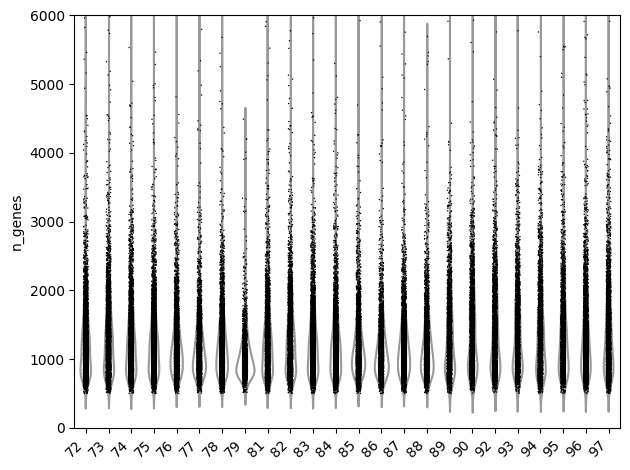

In [82]:
from matplotlib import rcParams

plt.rcParams['figure.figsize'] = 20,10
sns.reset_orig()
sns.violinplot(x = 'key', y = 'n_genes', data = dataframe.obs, color = 'white')
sns.stripplot(x = 'key', y = 'n_genes', data = dataframe.obs, color = 'black', size = 1)
plt.xticks(rotation=45, ha = 'right')
plt.ylim((0,6000))
plt.xlabel(None)
plt.tight_layout()
plt.savefig(fn + '_ngenes.png')
plt.show()

In [ ]:
#plotting n counts

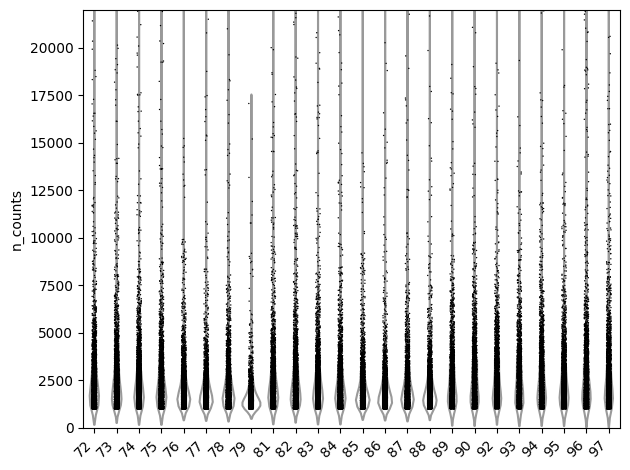

In [83]:
from matplotlib import rcParams

rcParams['figure.figsize'] = 20,10
sns.reset_orig()
sns.violinplot(x = 'key', y = 'n_counts', data = dataframe.obs, color = 'white')
sns.stripplot(x = 'key', y = 'n_counts', data = dataframe.obs, color = 'black', size = 1)
plt.xticks(rotation=45, ha = 'right')
plt.ylim((0,22000))
plt.xlabel(None)
plt.tight_layout()
plt.savefig(fn + '_ncounts.png')
plt.show()

In [ ]:
#extra make unique jic 

In [7]:
dataframe.obs_names_make_unique()
dataframe.var_names_make_unique()

In [56]:
#subset dataframe (only if needed)

In [28]:
batches = 'Run20_sample5'
dataframe = dataframe[dataframe.obs['key'] != batches]

In [30]:
dataframe.write('Testing_Raw_Dat_RNASEQ_Joined/tot_dat_CA_joined_10212024_Run20_sample5.h5ad')

In [ ]:
#downsampling code incased needed

In [41]:
dataframe.obs

,n_counts,n_genes
AAACCCAAGAGAAGGT.1,2369.0,525
AAACCCAAGCGCCTTG.1,1643.0,470
AAACCCAAGGTCACCC.1,679.0,379
AAACCCAAGTAGTCCT.1,1410.0,670
AAACCCACAATGTTGC.1,1121.0,543
...,...,...
TTTGTTGCATGGAGAC.1,1092.0,643
TTTGTTGGTAACGGTG.1,1090.0,391
TTTGTTGGTCACGACC.1,3352.0,754
TTTGTTGTCATGGGAG.1,1298.0,578


In [9]:
dataframe.obs['library_label']

TGGGCGTAGCTGTTCAL8TX_190228_01_E11    L8TX_190228_01_E11
TATGCCCGTACCGTTAL8TX_180221_01_C10    L8TX_180221_01_C10
AACTCAGGTACGACCCL8TX_190423_01_G06    L8TX_190423_01_G06
GTGCGGTCACATGTGTL8TX_190228_01_E11    L8TX_190228_01_E11
GACAGAGGTAGCGATGL8TX_180221_01_E10    L8TX_180221_01_E10
                                             ...        
TTTGTTGTCATCACCCL8TX_210107_02_H11    L8TX_210107_02_H11
TTTGTTGTCCCTCTTTL8TX_200625_01_D09    L8TX_200625_01_D09
TTTGTTGTCCGTATAGL8TX_201119_01_H08    L8TX_201119_01_H08
TTTGTTGTCCGTGTAAL8TX_210325_01_G07    L8TX_210325_01_G07
TTTGTTGTCTTACGGAL8TX_200827_01_B09    L8TX_200827_01_B09
Name: library_label, Length: 111142, dtype: category
Categories (765, object): ['L8TX_171026_01_A04', 'L8TX_171026_01_A05', 'L8TX_171026_01_B04', 'L8TX_171026_01_B05', ..., 'L8TX_220407_01_E06', 'L8TX_220414_01_B07', 'L8TX_220414_01_C07', 'L8TX_220421_01_G07']

In [10]:
sam=SAM(dataframe)
sam.preprocess_data() #log transforms and filters the data
sam.run(batch_key='key') #run with default parameters

RUNNING SAM
Iteration: 0, Convergence: 1.0


2026-06-09 04:37:25,445 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-09 04:37:35,646 - harmonypy - INFO - sklearn.KMeans initialization complete.


Iteration: 1, Convergence: 0.855672611760076


2026-06-09 04:38:10,071 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-09 04:38:20,761 - harmonypy - INFO - sklearn.KMeans initialization complete.


Iteration: 2, Convergence: 0.01382670866424796


2026-06-09 04:38:58,278 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-09 04:39:10,247 - harmonypy - INFO - sklearn.KMeans initialization complete.


Computing the UMAP embedding...
Elapsed time: 172.71414041519165 seconds


In [14]:
sam.adata

AnnData object with n_obs × n_vars = 19001 × 20032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts', 'key', 'hicat_merged', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match', 'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed', 'ss_subclass_nounlabeled_nmm_v2', 'subclass_id_label_crossed_NN

In [ ]:
#save raw counts in obsm

In [11]:
sam.adata.obsm['Raw_X'] = dataframe.X

In [12]:
sam.save_anndata('Active_SAM_joined/SAM_CJ_nonneural_cleaned_06082026.h5ad')